In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  
from scipy import stats

In [2]:
df=pd.read_csv(r"C:\Users\masir\Downloads\loan_data_set.csv")

In [4]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [7]:
#  0   Loan_ID             
#  1   Gender            
#  2   Married            
#  3   Dependents          
#  4   Education          
#  5   Self_Employed
# 6 Property_Area
# 7 Loan_Status

In [14]:
pd.crosstab(df['Gender'],df['Loan_Status'],margins=True) 

Loan_Status,N,Y,All
Gender,,,
Female,37,75,112
Male,150,339,489
All,187,414,601


In [15]:
pd.crosstab(df['Gender'],df['Loan_Status'],margins=True,normalize=True)

Loan_Status,N,Y,All
Gender,,,
Female,0.061564,0.124792,0.186356
Male,0.249584,0.564060,0.813644
All,0.311148,0.688852,1.000000


In [17]:
# Marginal probability
# p(N)=187/601=0.311
# p(Y)=414/601=0.688
# p(Female)=112/601=0.186
# p(Male)=489/601=0.813

In [18]:
# Joint probablity
# p(Male and Y)=339/601=0.564  
# p(Male and N)=150/601=0.249
# p(female and Y)=75/601=0.124
# p(female and N)=37/601=0.061

In [19]:
# conditional probability
# p(Male/Y) = p(male ∩ Y) / p(Y) = 0.564 / 0.688 = 0.820
# p(Male/N) = p(male ∩ N) / p(N) = 0.249 / 0.311 = 0.801
# p(Female/Y) = p(female ∩ Y) / p(Y) = 0.124 / 0.688 = 0.180
# p(Female/N) = p(female ∩ N) / p(N) = 0.061 / 0.311 = 0.196 

In [20]:
# cond1:p(male/y)=p(male)=0.820!=0.688
# cond2:p(male ∩ Y )=p(male)*p(Y)=0.820!=0.56416(0.813*0.688)
# hence gender and loan status are dependent variables

In [24]:
pd.crosstab(df['Married'],df['Loan_Status'],margins=True)

Loan_Status,N,Y,All
Married,,,
No,79,134,213
Yes,113,285,398
All,192,419,611


In [23]:
# Marginal probability
# p(LoanStatus=Y) = 419/611 = 0.685
# p(LoanStatus=N) = 192/611 = 0.314
# p(Married=Yes) = 398/611 = 0.651
# p(Married=No)  = 213/611 = 0.348

In [25]:
# joint probability
# p(LoanStatus=Y and Married=Yes) = 285/611 = 0.466
# p(LoanStatus=Y and Married=No)  = 134/611 = 0.219
# p(LoanStatus=N and Married=Yes) = 113/611 = 0.184
# p(LoanStatus=N and Married=No)  = 79/611  = 0.129


In [26]:
# conditional probability

# p(Loanstatus=Y / Married=Y) = p(Loanstatus=Y ∩ Married=Y) / p(Married=Y)
#                             = 0.466 / 0.651
#                             = 0.716

# p(Loanstatus=Y / Married=N) = p(Loanstatus=Y ∩ Married=N) / p(Married=N)
#                             = 0.219 / 0.348
#                             = 0.629

# p(Loanstatus=N / Married=Y) = p(Loanstatus=N ∩ Married=Y) / p(Married=Y)
#                             = 0.184 / 0.651
#                             = 0.282

# p(Loanstatus=N / Married=N) = p(Loanstatus=N ∩ Married=N) / p(Married=N)
#                             = 0.129 / 0.348
#                             = 0.370

In [27]:
# cond1=p(loanstatus=y/married=y)=p(loanstatus=y)=0.716!=0.685
# cond2=p(LoanStatus=Y and Married=Yes)=p(loanstatus=y)*p(Married=y)=0.466!=0.4459
# Both the columns are dependent to each other

In [29]:
pd.crosstab(df['Education'],df['Loan_Status'],margins=True)

Loan_Status,N,Y,All
Education,,,
Graduate,140,340,480
Not Graduate,52,82,134
All,192,422,614


In [1]:
# margin probability
# p(Graduate)=480/614=0.78
# p(Not Graduate)=134/614
# p(Y)=422/614=0.68
# p(N)=192/614

# Joint Probability
# p(Graduate and Y)=340/614=0.55

# conditional Probability
# p(graduate/y)=p(graduate and y)/p(y)=0.55/0.68=0.80

# cond1=p(graduate/y)=p(graduate)==>0.80!=0.78
# cond2=p(graduate and y)=p(graduate)*p(y)=0.80!=0.5304



In [7]:
df=pd.read_csv(r"C:\Users\masir\Downloads\healthcare_dataset.csv\healthcare_dataset.csv")

In [8]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [11]:
pd.crosstab(df['Gender'],df['Medical Condition'],margins=True)

Medical Condition,Arthritis,Asthma,Cancer,Diabetes,Hypertension,Obesity,All
Gender,,,,,,,
Female,4686,4553,4602,4651,4612,4622,27726
Male,4622,4632,4625,4653,4633,4609,27774
All,9308,9185,9227,9304,9245,9231,55500


In [12]:
# Find out the associativty between gender and medical condition
# marginal probability
# p(Male)=27774/55500=0.50
# p(Female)=27726/55500=0.49
# p(Arthrisis)=9308/55500=0.167
# p(Asthama)=9185/55500=0.165
# p(Cancer)=9227/55500=0.166
# p(Diabets)=9304/55500=0.167
# p(Hypertension)=9245/55500=0.166
# p(Obesity)=9231/55500=0.166

In [ ]:
# p(Male and Arthrsis)=4622/55500=0.0832
# p(male and asthama)=4632/55500=0.0834
# p(Male and cancer)=4625/55500=0.0833
# p(Male and Diabets)=4653/55500=0.0838
# p(Male and Hypertension)=4633/55500=0.0834
# p(Male and Obesity)=4609/55500=4609/55500

In [ ]:
# p(male/Arthrsis)=p(male and Arthrsis)/p(Arthrsis)=0.0832/0.167=0.50

In [ ]:
# there is no assciativity between male and medical condition Arthrsis

In [ ]:
# p(male/asthama)=p(male and asthama)/p(asthama)=4632/9185=0.504
# 0.50==0.50
# There is no associativity between male and medical condition asthama

In [2]:
# from this we can conclude that there is no asscotivatity between gender and medical condition

In [3]:
df=pd.read_csv(r"C:\Users\masir\Downloads\archive\car_price_dataset_medium.csv")

In [3]:
df.head()

,Car_ID,Brand,Model_Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Engine_CC,Max_Power_bhp,Mileage_kmpl,Seats,Price_USD
0,1,Audi,2005,197018,Diesel,Manual,First,4046,223.6,29.61,6,119611.94
1,2,BMW,2019,43467,Hybrid,Automatic,First,3731,248.4,21.66,5,90842.46
2,3,Kia,2012,153697,Hybrid,Automatic,Third,4925,465.5,12.14,6,78432.24
3,4,Mercedes,2015,38893,Petrol,Automatic,Second,3771,229.7,19.65,6,44568.89
4,5,Audi,2016,81329,Hybrid,Automatic,First,2817,573.2,7.74,5,8751.82


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Car_ID             1000 non-null   int64  
 1   Brand              1000 non-null   object 
 2   Model_Year         1000 non-null   int64  
 3   Kilometers_Driven  1000 non-null   int64  
 4   Fuel_Type          1000 non-null   object 
 5   Transmission       1000 non-null   object 
 6   Owner_Type         1000 non-null   object 
 7   Engine_CC          1000 non-null   int64  
 8   Max_Power_bhp      1000 non-null   float64
 9   Mileage_kmpl       1000 non-null   float64
 10  Seats              1000 non-null   int64  
 11  Price_USD          1000 non-null   float64
dtypes: float64(3), int64(5), object(4)
memory usage: 93.9+ KB


In [6]:
df[['Kilometers_Driven','Engine_CC','Max_Power_bhp','Mileage_kmpl','Seats','Price_USD']].describe() 

,Kilometers_Driven,Engine_CC,Max_Power_bhp,Mileage_kmpl,Seats,Price_USD
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,103397.074000,2878.299000,320.939900,17.34144,4.665000,59217.249420
std,57417.612935,1212.337697,160.384514,7.29799,1.802783,33545.254183
min,5155.000000,801.000000,40.500000,5.04000,2.000000,3028.420000
25%,52188.500000,1818.250000,184.825000,10.97000,4.000000,30030.822500
50%,102449.000000,2857.500000,314.650000,17.14500,5.000000,56806.745000
75%,152696.500000,3959.500000,455.300000,24.03500,6.000000,87088.897500
max,199812.000000,4996.000000,599.600000,29.99000,7.000000,119611.940000


In [7]:
# the dataset that im working is having the range of
# kilometers driven -->5155km  - 199812km
# Engine_CC         -->801cc - 4996cc
# max_power_bnhp    -->40bnhp  - 599bnhp
# Mileage_kmpl      -->5kmpl   - 29kmpl
# seats             -->2-   7
# price_USD         -->3028 -- 119611

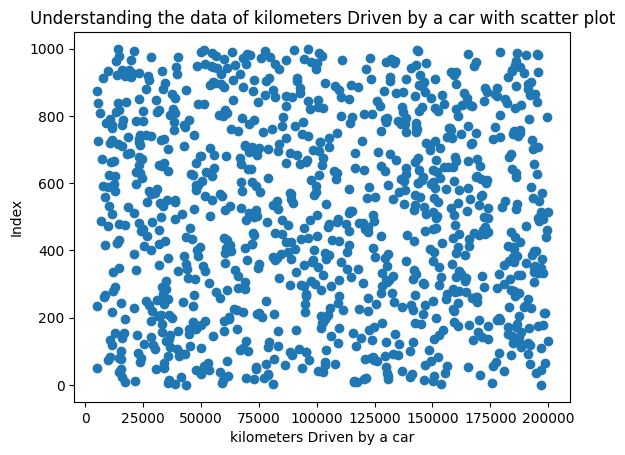

In [12]:
plt.scatter(x=df['Kilometers_Driven'],y=df['Kilometers_Driven'].index)
plt.title('Understanding the data of kilometers Driven by a car with scatter plot')
plt.xlabel('kilometers Driven by a car')
plt.ylabel('Index')
plt.show()

In [19]:
print(df['Kilometers_Driven'].skew()) 
print(df['Kilometers_Driven'].mean())
print(df['Kilometers_Driven'].var()) 
print(df['Kilometers_Driven'].std())

-0.011047609371800066
103397.074
3296782275.1516757
57417.612934984296


<Axes: >

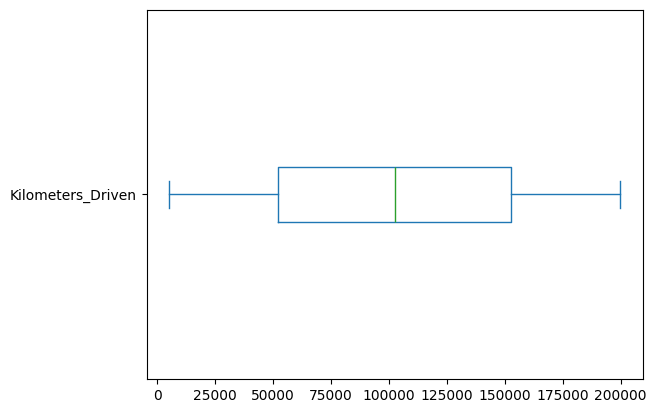

In [20]:
df['Kilometers_Driven'].plot(kind='box',vert=False)

In [ ]:
# the average deviation from the mean is around 57417
# the data is spread from 0 to 200000
# The data points are randomly distributed
# The data has a very large spread,indicating high variability
# The dataset is in  symmentrical distribution
# The dataset has no significant outliers

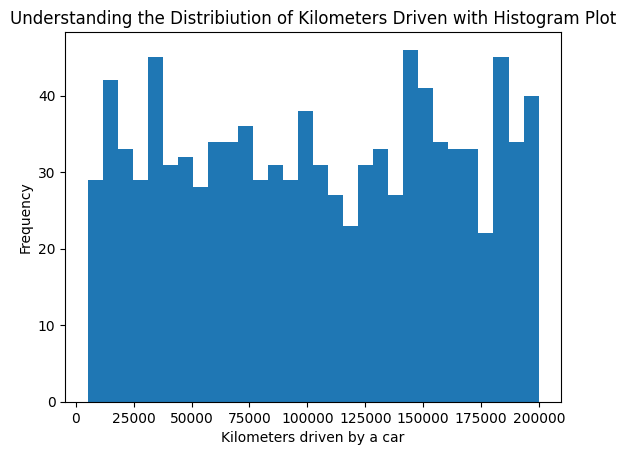

In [21]:
df['Kilometers_Driven'].plot(kind='hist',bins=30)
plt.title("Understanding the Distribiution of Kilometers Driven with Histogram Plot")
plt.xlabel("Kilometers driven by a car")
plt.ylabel("Frequency")
plt.show() 

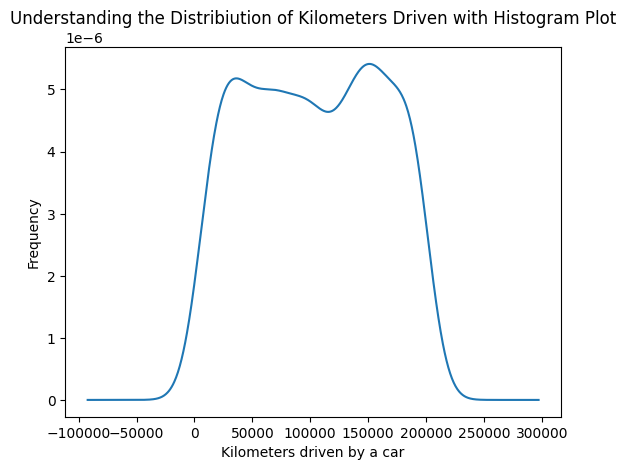

In [22]:
df['Kilometers_Driven'].plot(kind='density')
plt.title("Understanding the Distribiution of Kilometers Driven with Histogram Plot")
plt.xlabel("Kilometers driven by a car")
plt.ylabel("Frequency")
plt.show()

In [4]:
q1=df['Kilometers_Driven'].quantile(0.25)
q2=df['Kilometers_Driven'].quantile(0.50)
q3=df['Kilometers_Driven'].quantile(0.75)
IQR=q3-q1
low_whisker=q1-1.5*IQR
high_whisker=q3+1.5*IQR


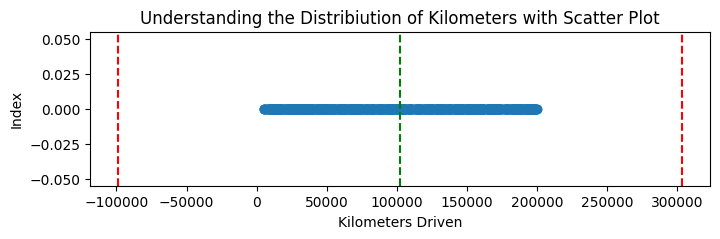

In [5]:
plt.figure(figsize=(8,2))
plt.scatter(x=df['Kilometers_Driven'],y=[0]*len(df['Kilometers_Driven']))
plt.title("Understanding the Distribiution of Kilometers with Scatter Plot")
plt.axvline(q2,linestyle='--',c='green',label='median')
plt.axvline(low_whisker,linestyle='--',c='red')
plt.axvline(high_whisker,linestyle='--',c='red')
plt.xlabel('Kilometers Driven')
plt.ylabel('Index')
plt.show()

In [6]:
# from this we can we can understand there is no significant outliers

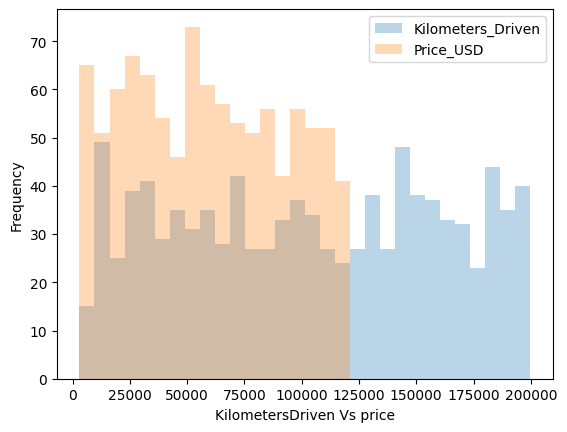

In [9]:
df[['Kilometers_Driven','Price_USD']].plot(kind='hist',bins=30,alpha=0.3)
plt.xlabel('KilometersDriven Vs price')
plt.ylabel("Frequency")
plt.show()

In [10]:
# The histogaram give tells there is no significant outliers 
# The range of price was between 0 and 125000
# The range of the kilometersDriven was around 0 to 200000

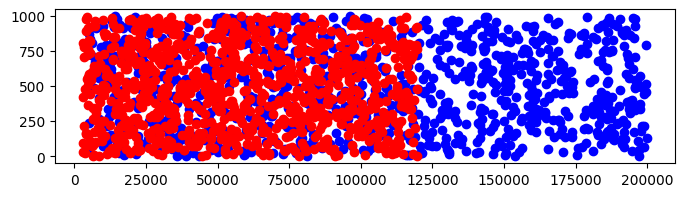

In [17]:
plt.figure(figsize=(8,2))
plt.scatter(x=df['Kilometers_Driven'],y=df['Kilometers_Driven'].index,c='blue',label='kilometers Driven')
plt.scatter(x=df['Price_USD'],y=df['Price_USD'].index,c='red',label='price')
plt.show()

In [18]:
# the kilometers_Driven data was spread more compared to the price_USD

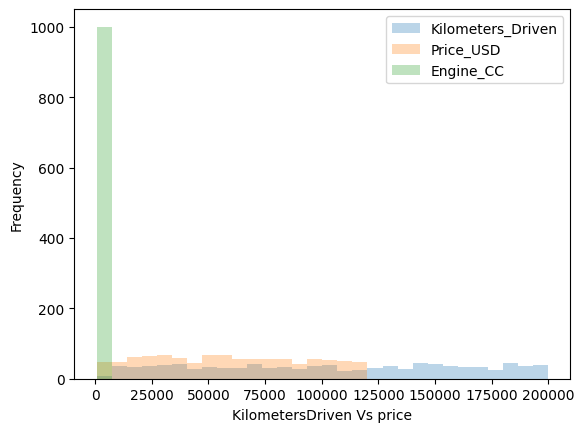

In [19]:
df[['Kilometers_Driven','Price_USD','Engine_CC']].plot(kind='hist',bins=30,alpha=0.3)
plt.xlabel('KilometersDriven Vs price')
plt.ylabel("Frequency")
plt.show()

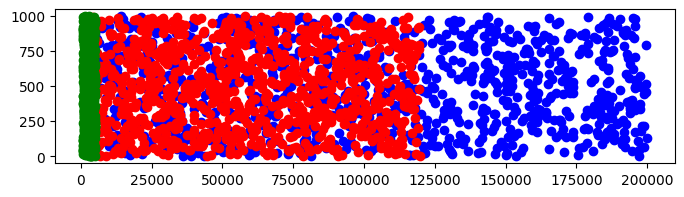

In [20]:
plt.figure(figsize=(8,2))
plt.scatter(x=df['Kilometers_Driven'],y=df['Kilometers_Driven'].index,c='blue',label='kilometers Driven')
plt.scatter(x=df['Price_USD'],y=df['Price_USD'].index,c='red',label='price')
plt.scatter(x=df['Engine_CC'],y=df['Engine_CC'].index,c='green',label='price')
plt.show()

In [21]:
df=pd.read_csv(r"C:\Users\masir\Downloads\original_dataset.csv")

In [22]:
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  object 
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  object 
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  object 
 15  num_of_open_account

In [24]:
df.shape

(20000, 22)

In [56]:
df['annual_income'].describe()

count     20000.000000
mean      43549.637765
std       28668.579671
min        6000.000000
25%       24260.752500
50%       36585.260000
75%       54677.917500
max      400000.000000
Name: annual_income, dtype: float64

In [54]:
df['loan_amount'].skew()

0.25309257045229494

In [55]:
df['loan_amount'].kurt()

-0.32712232109467676

In [53]:
df['loan_amount'].var()

74053004.0511205

In [31]:
df['annual_income']

0        24240.19
1        20172.98
2        26181.80
3        11873.84
4        25326.44
           ...   
19995    39640.08
19996    32062.90
19997    18642.02
19998    22181.39
19999    23737.70
Name: annual_income, Length: 20000, dtype: float64

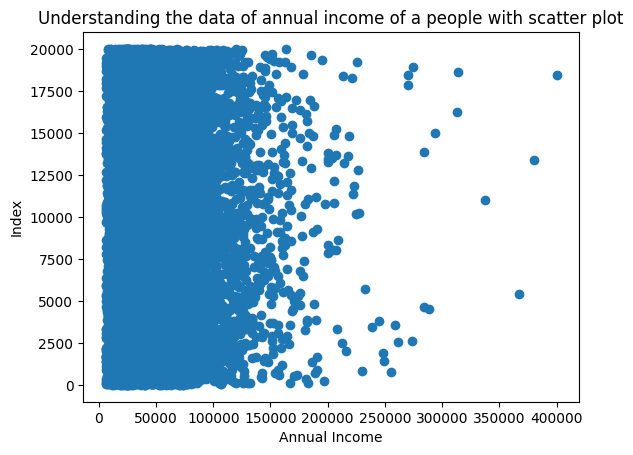

In [34]:
plt.scatter(x=df['annual_income'],y=df['annual_income'].index)
plt.title('Understanding the data of annual income of a people with scatter plot')
plt.xlabel('Annual Income')
plt.ylabel('Index')
plt.show() 

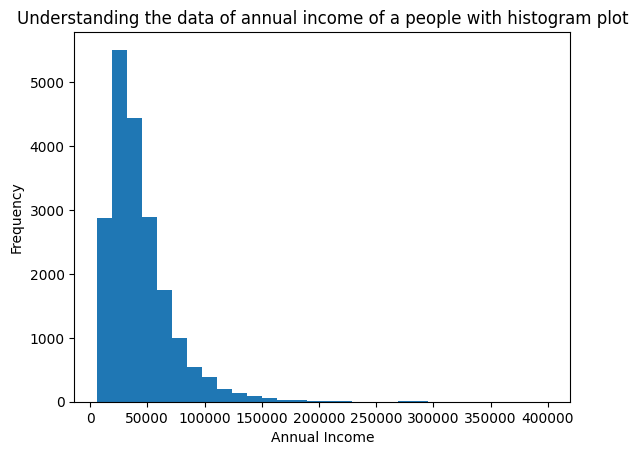

In [37]:
df["annual_income"].plot(kind="hist",bins=30)
plt.title("Understanding the data of annual income of a people with histogram plot")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.show()

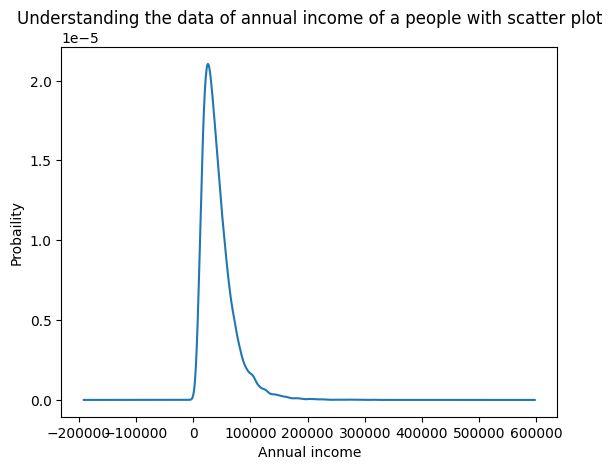

In [36]:
df["annual_income"].plot(kind="density")
plt.title("Understanding the data of annual income of a people with Density Plot")
plt.xlabel("Annual income")
plt.ylabel("Probaility")
plt.show()

In [39]:
# Outlier Detection Using Distribution
q1 = df["annual_income"].quantile(0.25)
q2 = df["annual_income"].quantile(0.50)
q3 = df["annual_income"].quantile(0.75)

IQR = q3 - q1

low_whisker = q1 - 1.5*IQR
high_whisker = q3 + 1.5*IQR

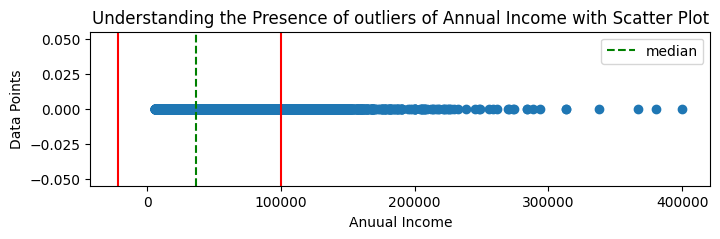

In [41]:
plt.figure(figsize=(8,2))
plt.scatter(x=df["annual_income"],y = [0]*len(df["annual_income"]))
plt.title("Understanding the Presence of outliers of Annual Income with Scatter Plot") 
plt.axvline(q2,linestyle="--",c="green",label="median")
plt.axvline(low_whisker,linestyle="-",c="red")
plt.axvline(high_whisker,linestyle="-",c="red")
plt.xlabel("Anuual Income")
plt.ylabel("Data Points")
plt.legend()
plt.show() 

C:\Users\masir\AppData\Local\Temp\ipykernel_11684\78154119.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


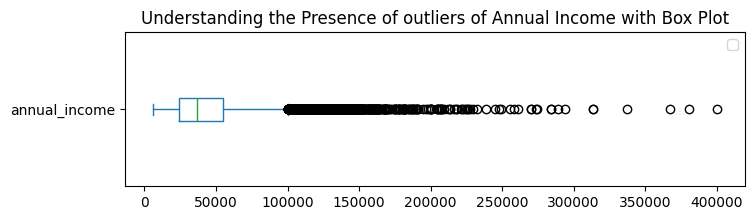

In [44]:
plt.figure(figsize=(8,2))
df['annual_income'].plot(kind='box',vert=False)
plt.title("Understanding the Presence of outliers of Annual Income with Box Plot") 
plt.legend()
plt.show()

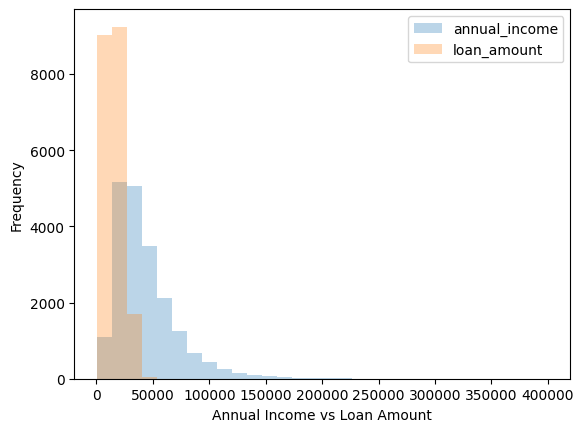

In [45]:
df[["annual_income","loan_amount"]].plot(kind="hist",bins=30,alpha=0.3)
plt.xlabel("Annual Income vs Loan Amount")
plt.ylabel("Frequency")
plt.show()

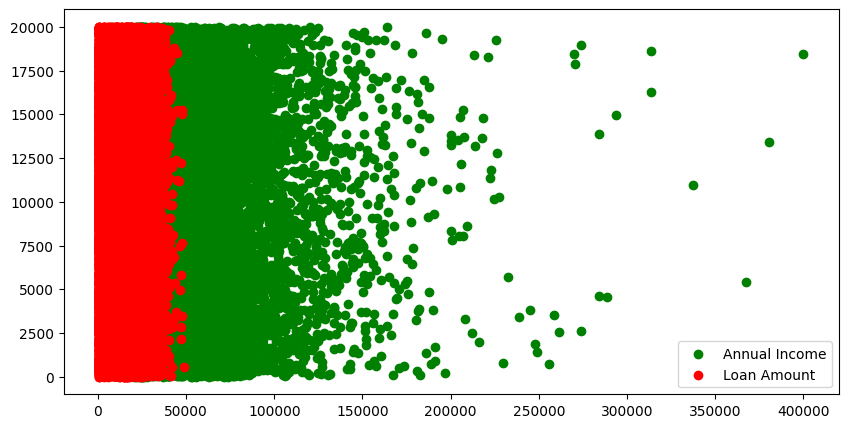

In [48]:
plt.figure(figsize=(10,5))
plt.scatter(x=df["annual_income"],y=df["annual_income"].index,c="green",label="Annual Income")
plt.scatter(x=df["loan_amount"],y=df["loan_amount"].index,c="red",label="Loan Amount")
plt.legend()
plt.show()

In [221]:
df=pd.read_csv(r"C:\Users\masir\Downloads\adult.csv\adult.csv")

In [4]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [6]:
numerical_values=df[['age','fnlwgt','education.num','capital.gain','capital.loss','hours.per.week','income']]

In [7]:
numerical_values

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income
0,90,77053,9,0,4356,40,<=50K
1,82,132870,9,0,4356,18,<=50K
2,66,186061,10,0,4356,40,<=50K
3,54,140359,4,0,3900,40,<=50K
4,41,264663,10,0,3900,40,<=50K
...,...,...,...,...,...,...,...
32556,22,310152,10,0,0,40,<=50K
32557,27,257302,12,0,0,38,<=50K
32558,40,154374,9,0,0,40,>50K
32559,58,151910,9,0,0,40,<=50K


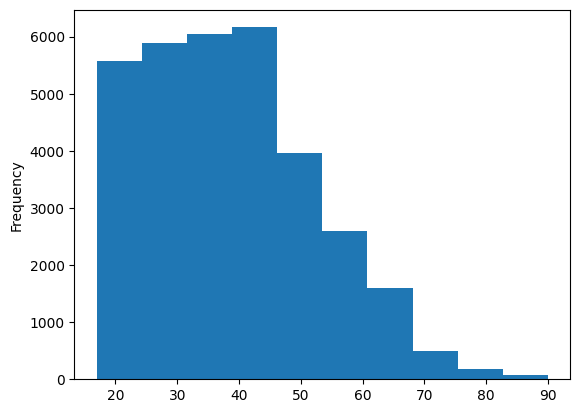

In [8]:
numerical_values['age'].plot(kind='hist')
plt.show()

In [9]:
# There are no gaps in the histogram because a histogram groups data into continuous intervals (bins), not individual values. Each bar represents a range of ages like 20–30 or 30–40. Since there are people in almost every age interval, all bins contain some data, so no gaps appear. Even though age is recorded as integers, it is treated as a continuous variable in a histogram.
# Gaps appear only when an entire interval has zero frequency. Since the Adult dataset has observations in all age ranges, every bin has some frequency, so no empty spaces are visible.

In [10]:
df['age'].describe()

count    32561.000000
mean        38.581647
std         13.640433
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64

In [11]:
def function(x):
    if 0<x<=28:
        return '0-28'
    elif 28<x<=37:
        return '29-37'
    elif 37<x<=48:
        return '38-48'
    else:
        return '49-90'
numerical_values['age']=numerical_values['age'].apply(function)

C:\Users\masir\AppData\Local\Temp\ipykernel_5968\2385767775.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  numerical_values['age']=numerical_values['age'].apply(function)


In [12]:
numerical_values.head()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income
0,49-90,77053,9,0,4356,40,<=50K
1,49-90,132870,9,0,4356,18,<=50K
2,49-90,186061,10,0,4356,40,<=50K
3,49-90,140359,4,0,3900,40,<=50K
4,38-48,264663,10,0,3900,40,<=50K


In [13]:
numerical_values['age'].value_counts()

age
0-28     8898
38-48    8241
29-37    7783
49-90    7639
Name: count, dtype: int64

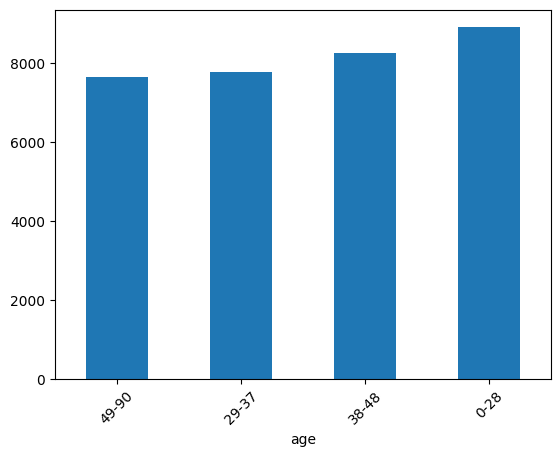

In [14]:
numerical_values['age'].value_counts().sort_values().plot(kind='bar')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# The highest number of individuals fall in the 0–28 age group, indicating that young adults form the largest portion of the dataset.
# The 38–48 age group is the second most populated group.
# The 49–90 age group has the lowest frequency, showing that fewer older individuals are present in the dataset.
# This indicates that the dataset is skewed toward younger and middle-aged adults.

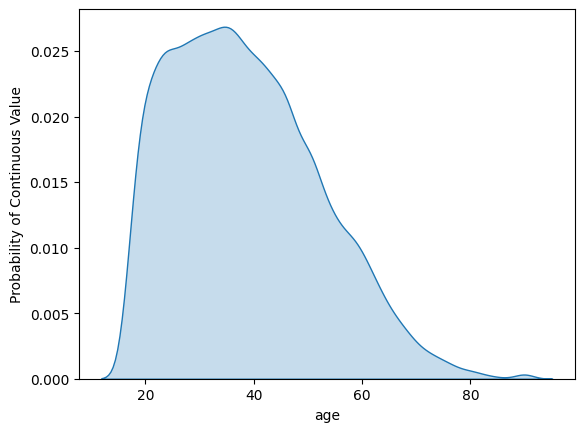

In [23]:
sns.kdeplot(data=df,x='age',fill=True)
plt.ylabel('Probability of Continuous Value')
plt.show() 

In [25]:
df['age'].describe()

count    32561.000000
mean        38.581647
std         13.640433
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64

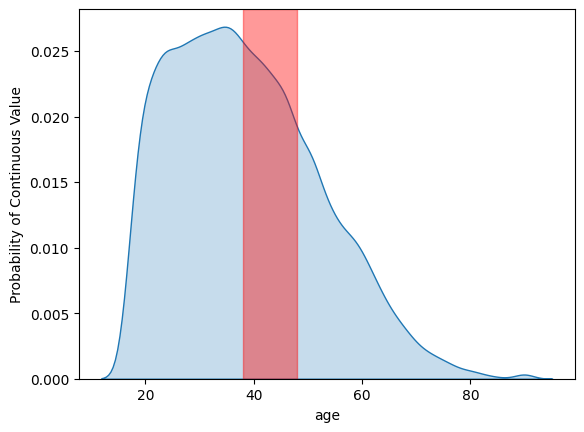

In [26]:
sns.kdeplot(data=df,x='age',fill=True)
plt.ylabel('Probability of Continuous Value')
plt.axvspan(38,48,color='Red',alpha=0.4)
plt.show() 

In [27]:
# np.trapezoid--> findout the area under the curve

In [29]:
from scipy.stats import gaussian_kde
kde_curve = gaussian_kde(df['age'])

In [30]:
points=np.linspace(38,48,1000)

In [34]:

area=float(np.trapz(kde_curve(points),points).round(3))

In [35]:
area
# probability of the given interval is 38 to 48

0.231

In [36]:
numerical_values

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income
0,49-90,77053,9,0,4356,40,<=50K
1,49-90,132870,9,0,4356,18,<=50K
2,49-90,186061,10,0,4356,40,<=50K
3,49-90,140359,4,0,3900,40,<=50K
4,38-48,264663,10,0,3900,40,<=50K
...,...,...,...,...,...,...,...
32556,0-28,310152,10,0,0,40,<=50K
32557,0-28,257302,12,0,0,38,<=50K
32558,38-48,154374,9,0,0,40,>50K
32559,49-90,151910,9,0,0,40,<=50K


In [93]:
sample=pd.DataFrame(numerical_values['education.num'].value_counts())
sample.rename(columns={'count':'Frequency'},inplace=True)
sample.sort_index(inplace=True)
sample.reset_index(inplace=True)
sample

,education.num,Frequency
0,1,51
1,2,168
2,3,333
3,4,646
4,5,514
5,6,933
6,7,1175
7,8,433
8,9,10501
9,10,7291


In [94]:
sample['PMF']=sample['Frequency']/sample['Frequency'].sum()

In [74]:
sample

,education.num,Frequency,PMF
0,1,51,0.001566
1,2,168,0.005160
2,3,333,0.010227
3,4,646,0.019840
4,5,514,0.015786
5,6,933,0.028654
6,7,1175,0.036086
7,8,433,0.013298
8,9,10501,0.322502
9,10,7291,0.223918


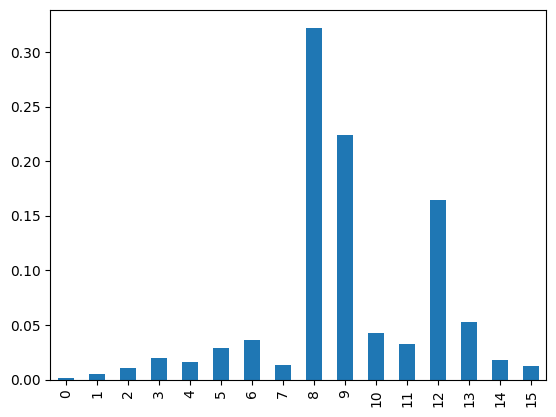

In [76]:
sample['PMF'].plot(kind='bar')
plt .show()

In [85]:
sample=numerical_values['fnlwgt']

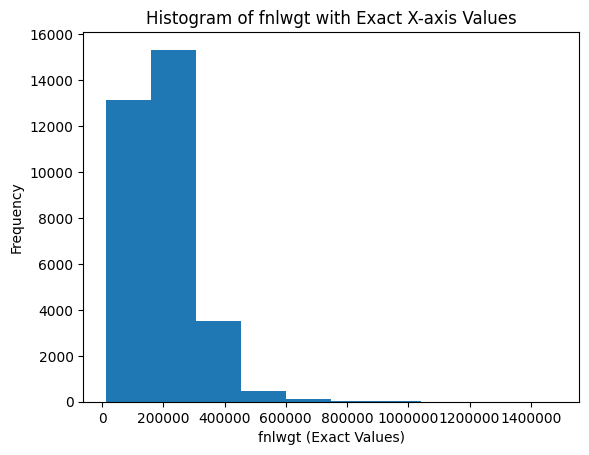

In [84]:
ax = numerical_values['fnlwgt'].plot(kind='hist')
ax.ticklabel_format(style='plain', axis='x')   # removes scientific notation
plt.xlabel("fnlwgt (Exact Values)")
plt.ylabel("Frequency")
plt.title("Histogram of fnlwgt with Exact X-axis Values")
plt.show()

In [90]:
sample=pd.DataFrame(sample[:10])
sample

,fnlwgt
0,77053
1,132870
2,186061
3,140359
4,264663
5,216864
6,150601
7,88638
8,422013
9,70037


In [91]:
from scipy.stats import gaussian_kde
x = sample['fnlwgt']
kde = gaussian_kde(x)
sample['fnlwgt_pdf'] = kde(x) 

In [92]:
sample

,fnlwgt,fnlwgt_pdf
0,77053,3.133036e-06
1,132870,3.827095e-06
2,186061,3.348910e-06
3,140359,3.820892e-06
4,264663,1.768469e-06
5,216864,2.760400e-06
6,150601,3.775836e-06
7,88638,3.376683e-06
8,422013,6.383070e-07
9,70037,2.966384e-06


In [95]:
sample=pd.DataFrame(numerical_values['education.num'].value_counts())
sample.rename(columns={'count':'Frequency'},inplace=True)
sample.sort_index(inplace=True)
sample.reset_index(inplace=True)
sample

,education.num,Frequency
0,1,51
1,2,168
2,3,333
3,4,646
4,5,514
5,6,933
6,7,1175
7,8,433
8,9,10501
9,10,7291


In [96]:
sample['PMF']=sample['Frequency']/sample['Frequency'].sum()
sample

,education.num,Frequency,PMF
0,1,51,0.001566
1,2,168,0.005160
2,3,333,0.010227
3,4,646,0.019840
4,5,514,0.015786
5,6,933,0.028654
6,7,1175,0.036086
7,8,433,0.013298
8,9,10501,0.322502
9,10,7291,0.223918


In [98]:
sample['cdf']=sample['PMF'].cumsum()
sample

,education.num,Frequency,PMF,cdf
0,1,51,0.001566,0.001566
1,2,168,0.005160,0.006726
2,3,333,0.010227,0.016953
3,4,646,0.019840,0.036792
4,5,514,0.015786,0.052578
5,6,933,0.028654,0.081232
6,7,1175,0.036086,0.117318
7,8,433,0.013298,0.130616
8,9,10501,0.322502,0.453119
9,10,7291,0.223918,0.677037


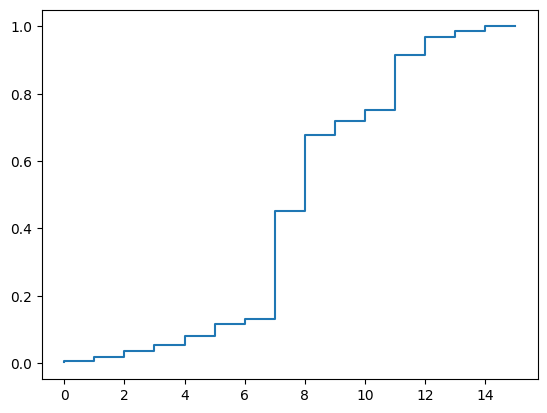

In [101]:
plt.step(x=sample.index,y=sample['cdf'].values)
plt.show()

In [ ]:
# The CDF shows the cumulative probability of education level up to a given value.
# At any point on the x-axis, the y-value tells the probability that a person’s education number is less than or equal to that value.

# The steep rise between around education-num 7 and 9 means a large portion of people lie in this range.
# This indicates that most individuals have education levels around high-school / some-college range.

# By education-num ≈ 12, the CDF reaches close to 1.0, meaning:

# Almost the entire population has education level ≤ 12.

# The curve starts near 0 at low education values, showing:

# Very few people have extremely low education numbers.

# After education-num ≈ 13, the curve becomes almost flat, meaning:

# Very few people have very high education levels (graduate or professional degrees).

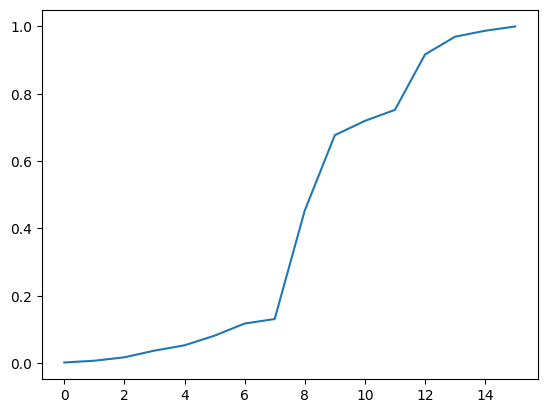

In [103]:
plt.plot(sample.index,sample.cdf)

In [220]:
df['marital.status'].unique()

array(['Widowed', 'Divorced', 'Separated', 'Never-married',
       'Married-civ-spouse', 'Married-spouse-absent', 'Married-AF-spouse'],
      dtype=object)

In [136]:
divorced=df[df['marital.status']=='Divorced'][['marital.status','age']]

In [137]:
divorced.sort_values(by='age',inplace=True)
sample=divorced['age'].value_counts()


In [139]:
sample=pd.DataFrame(sample)

In [141]:
sample.reset_index(inplace=True)
sample.head()

,index,age,count
0,0,45,178
1,1,42,173
2,2,41,171
3,3,40,166
4,4,39,166


In [144]:
sample

,age,count
0,45,178
1,42,173
2,41,171
3,40,166
4,39,166
...,...,...
59,83,1
60,88,1
61,18,1
62,77,1


In [145]:
sample.sort_values(by='age',inplace=True)
sample.reset_index(drop=True,inplace=True)
sample

,age,count
0,18,1
1,19,6
2,20,7
3,21,4
4,22,16
...,...,...
59,77,1
60,81,3
61,83,1
62,88,1


In [146]:
sample['pmf']=sample['count']/sample['count'].sum()

In [147]:
sample

,age,count,pmf
0,18,1,0.000225
1,19,6,0.001350
2,20,7,0.001576
3,21,4,0.000900
4,22,16,0.003601
...,...,...,...
59,77,1,0.000225
60,81,3,0.000675
61,83,1,0.000225
62,88,1,0.000225


In [148]:
sample['cdf']=sample['pmf'].cumsum()

In [149]:
sample

,age,count,pmf,cdf
0,18,1,0.000225,0.000225
1,19,6,0.001350,0.001576
2,20,7,0.001576,0.003151
3,21,4,0.000900,0.004051
4,22,16,0.003601,0.007652
...,...,...,...,...
59,77,1,0.000225,0.998650
60,81,3,0.000675,0.999325
61,83,1,0.000225,0.999550
62,88,1,0.000225,0.999775


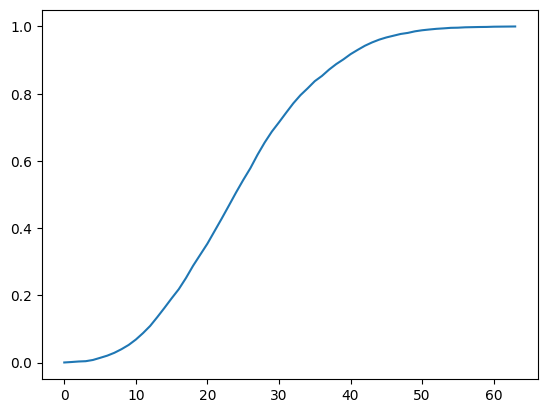

In [150]:
plt.plot(sample['cdf'])
plt.show()

In [120]:
# from visual analysis 80 percent of  people who got divorced there  age was less than 40

In [165]:
divorced=df[df['marital.status']=='Never-married'][['marital.status','age']]

In [166]:
divorced.sort_values(by='age',inplace=True)
sample1=divorced['age'].value_counts()

In [167]:
sample1=pd.DataFrame(sample1)
sample1.head()

,count
age,
23,717
20,695
19,681
21,651
22,651


In [168]:
sample1.reset_index(inplace=True)
sample1

,age,count
0,23,717
1,20,695
2,19,681
3,21,651
4,22,651
...,...,...
62,78,2
63,74,1
64,82,1
65,84,1


In [171]:
sample1.sort_values(by='age')

,age,count
11,17,393
7,18,539
2,19,681
1,20,695
3,21,651
...,...,...
58,80,3
64,82,1
65,84,1
66,86,1


In [172]:
sample1['pmf']=sample1['count']/sample1['count'].sum()

In [173]:
sample1['cdf']=sample1['pmf'].cumsum()

In [174]:
sample1

,age,count,pmf,cdf
0,23,717,0.067116,0.067116
1,20,695,0.065057,0.132173
2,19,681,0.063746,0.195919
3,21,651,0.060938,0.256857
4,22,651,0.060938,0.317795
...,...,...,...,...
62,78,2,0.000187,0.999626
63,74,1,0.000094,0.999719
64,82,1,0.000094,0.999813
65,84,1,0.000094,0.999906


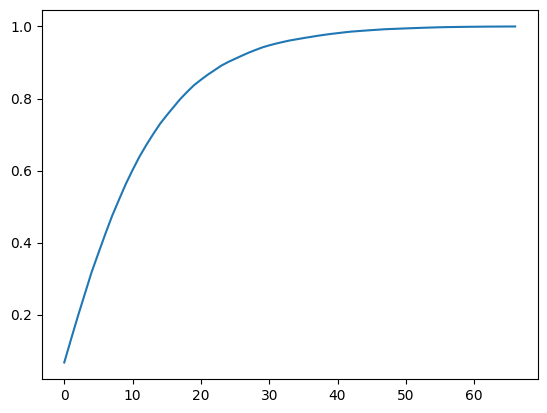

In [175]:
plt.plot(sample1['cdf'])
plt.show()

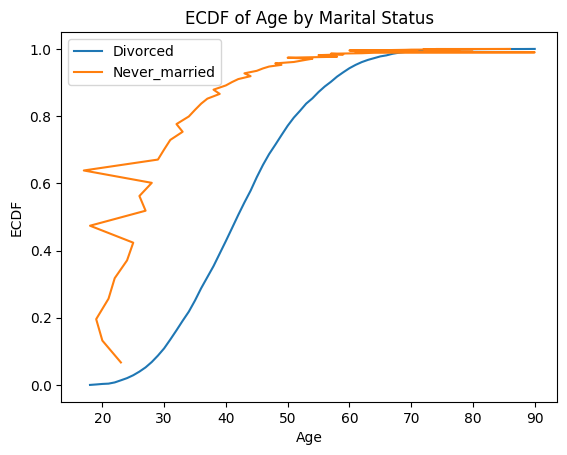

In [178]:
plt.plot(sample['age'], sample['cdf'], label='Divorced')
plt.plot(sample1['age'], sample1['cdf'], label='Never_married')
plt.legend()
plt.xlabel("Age")
plt.ylabel("ECDF")
plt.title("ECDF of Age by Marital Status")
plt.show()


In [179]:
# The approximate 85–90 percent of never_married people are less than 30 years of age
# The approximate 10–15 percent of never_married people are above 30 years of age
# The approximate 80–85 percent of divorced people are less than 45 years of age
# The approximate 15–20 percent of divorced people fall in the age range of 45 to 70 years

In [232]:
divorced=df[df['marital.status']=='Widowed'][['marital.status','age']]

In [233]:
divorced.sort_values(by='age',inplace=True)
sample2=divorced['age'].value_counts()

In [234]:
sample2=pd.DataFrame(sample2)
sample2.head()

,count
age,
62,41
65,38
55,36
66,36
64,36


In [235]:
sample2.reset_index(inplace=True)
sample2

,age,count
0,62,41
1,65,38
2,55,36
3,66,36
4,64,36
...,...,...
60,34,2
61,25,1
62,29,1
63,87,1


In [236]:
sample2.sort_values(by='age',inplace=True)

In [237]:
sample2['pmf']=sample2['count']/sample2['count'].sum()

In [238]:
sample2['cdf']=sample2['pmf'].cumsum()

In [239]:
sample2

,age,count,pmf,cdf
64,18,1,0.001007,0.001007
54,22,2,0.002014,0.003021
61,25,1,0.001007,0.004028
55,26,2,0.002014,0.006042
58,27,2,0.002014,0.008056
...,...,...,...,...
53,83,3,0.003021,0.985901
50,84,5,0.005035,0.990937
56,85,2,0.002014,0.992951
63,87,1,0.001007,0.993958


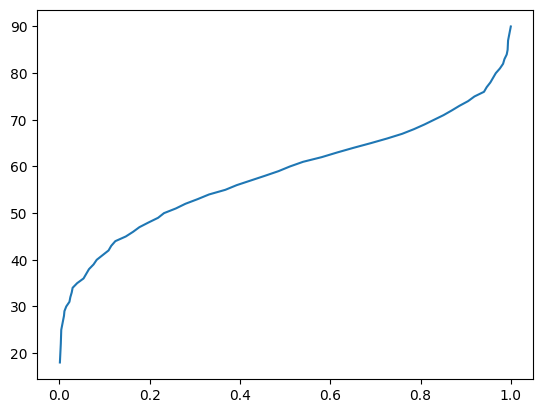

In [240]:
plt.plot(sample2['cdf'],sample2['age'])
plt.show()

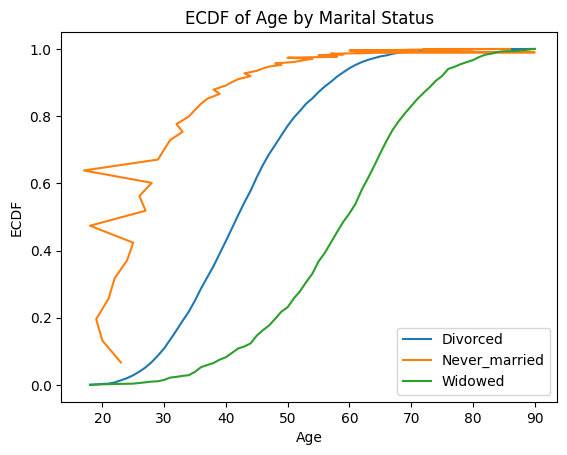

In [241]:
plt.plot(sample['age'], sample['cdf'], label='Divorced')
plt.plot(sample1['age'], sample1['cdf'], label='Never_married')
plt.plot(sample2['age'], sample2['cdf'], label='Widowed')
plt.legend()
plt.xlabel("Age")
plt.ylabel("ECDF")
plt.title("ECDF of Age by Marital Status")
plt.show()


In [196]:
# The aprroximate  80-85 percent of people has never married whose age was less than 30 years
# The aprroximate  15-20 percent of people has never married whose age was greater than 30 years
# The approximate 80–85 percent of divorced people are less than 45 years of age
# The approximate 15–20 percent of divorced people fall in the age range of 45 to 70 years
# The approximate 80 - 85 percent of widowed people are less than age of 70 years
# The approximate 15 to 20 percent of widowed people are fall in the age group of 70 to 90

In [223]:
divorced=df[df['marital.status']=='Married-AF-spouse'][['marital.status','age']]
divorced.head()

,marital.status,age
2871,Married-AF-spouse,40
3850,Married-AF-spouse,75
4263,Married-AF-spouse,19
5941,Married-AF-spouse,28
6720,Married-AF-spouse,19


In [224]:
divorced.sort_values(by='age',inplace=True)
sample3=divorced['age'].value_counts()

In [225]:
sample3=pd.DataFrame(sample3)
sample3.head()

,count
age,
29,3
30,3
19,2
26,2
35,2


In [227]:
sample3.reset_index(inplace=True)
sample3

,age,count
0,29,3
1,30,3
2,19,2
3,26,2
4,35,2
5,22,1
6,24,1
7,27,1
8,28,1
9,32,1


In [242]:
sample3.sort_values(by='age',inplace=True)

In [243]:
sample3['pmf']=sample3['count']/sample3['count'].sum()

In [244]:
sample3['cdf']=sample3['pmf'].cumsum()

In [245]:
sample3

,age,count,pmf,cdf
2,19,2,0.086957,0.086957
5,22,1,0.043478,0.130435
6,24,1,0.043478,0.173913
3,26,2,0.086957,0.260870
7,27,1,0.043478,0.304348
8,28,1,0.043478,0.347826
0,29,3,0.130435,0.478261
1,30,3,0.130435,0.608696
9,32,1,0.043478,0.652174
10,34,1,0.043478,0.695652


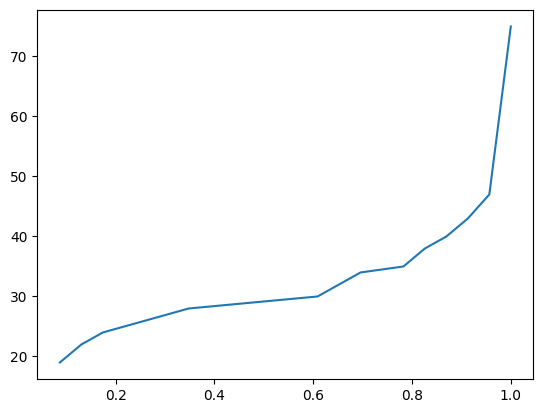

In [246]:
plt.plot(sample3['cdf'],sample3['age'])
plt.show()

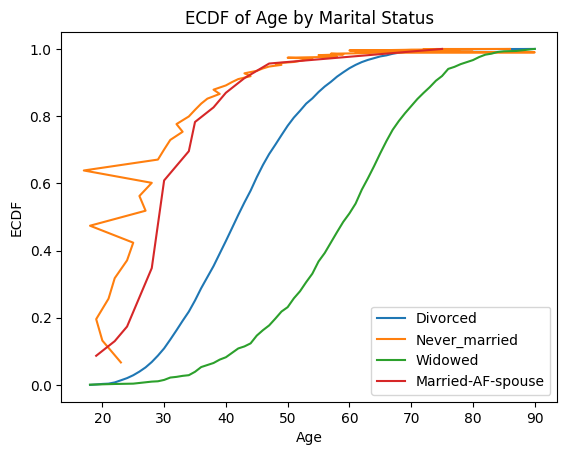

In [249]:
plt.plot(sample['age'], sample['cdf'], label='Divorced')
plt.plot(sample1['age'], sample1['cdf'], label='Never_married')
plt.plot(sample2['age'], sample2['cdf'], label='Widowed')
plt.plot(sample3['age'], sample3['cdf'], label='Married-AF-spouse')
plt.legend()
plt.xlabel("Age")
plt.ylabel("ECDF")
plt.title("ECDF of Age by Marital Status")
plt.show()


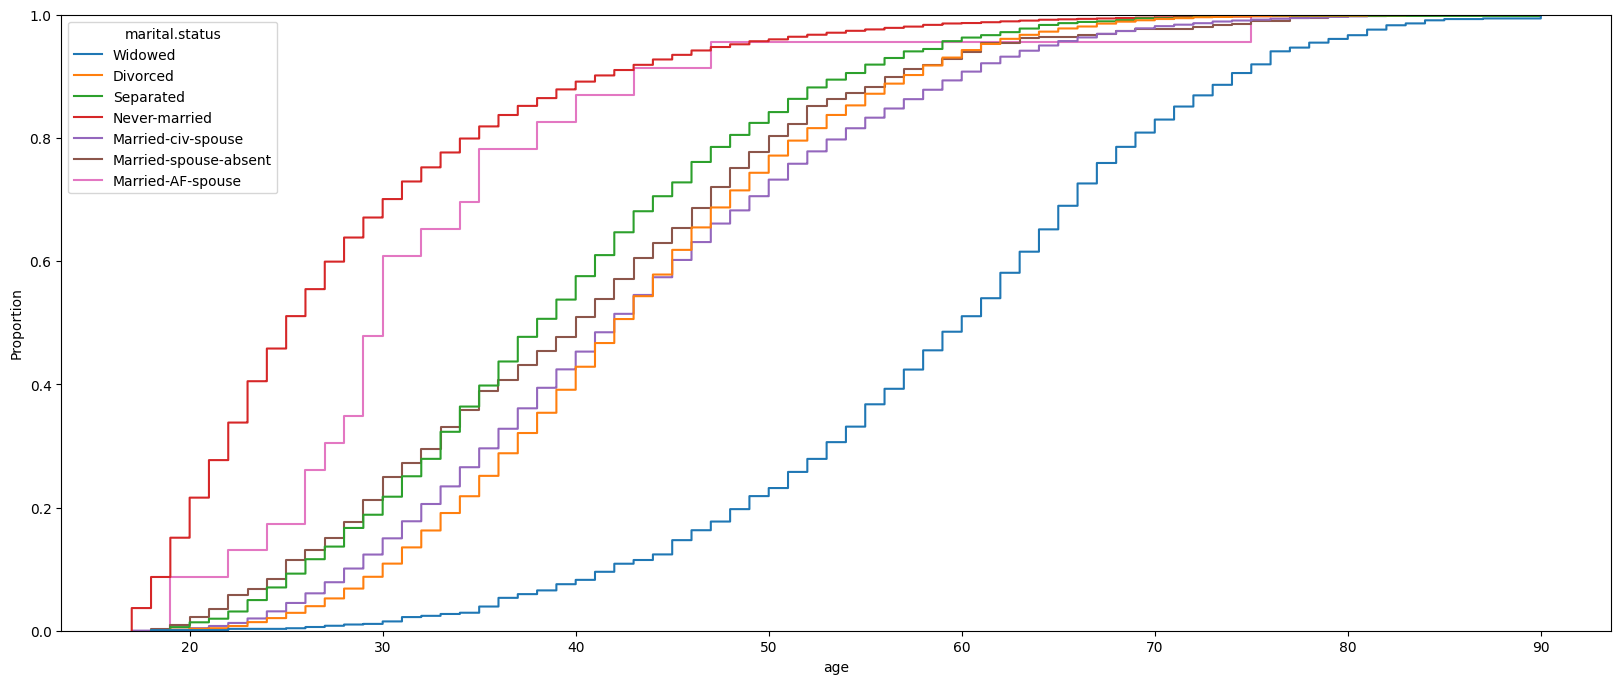

In [200]:
plt.figure(figsize=(20,8))
sns.ecdfplot(data=df,x="age",hue="marital.status")
plt.show() 

In [251]:
sample3[(sample3['age']>=48) & (sample3['age']<=75)]

,age,count,pmf,cdf
15,75,1,0.043478,1.0


In [ ]:
# The majority of Married-AF-spouse individuals lie between the age group of 48 and 75

In [2]:
# small continuous dataset
data = [55, 56, 57, 60, 62, 63, 68, 70, 72, 75]
df = pd.DataFrame({"Weight": data})


In [3]:
bins = [55, 60, 65, 70, 75]


In [4]:
freq, bin_edges = np.histogram(df["Weight"], bins=bins)

In [5]:
freq,bin_edges

(array([3, 3, 1, 3]), array([55, 60, 65, 70, 75]))

In [6]:
total = len(df)
bin_width = bin_edges[1] - bin_edges[0]

pdf = freq / (total * bin_width)


In [8]:
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

pdf_df = pd.DataFrame({
    "bin_range": [f"{bin_edges[i]}–{bin_edges[i+1]}" for i in range(len(freq))],
    "frequency": freq,
    "pdf": pdf
})


In [9]:
pdf_df

,bin_range,frequency,pdf
0,55–60,3,0.06
1,60–65,3,0.06
2,65–70,1,0.02
3,70–75,3,0.06


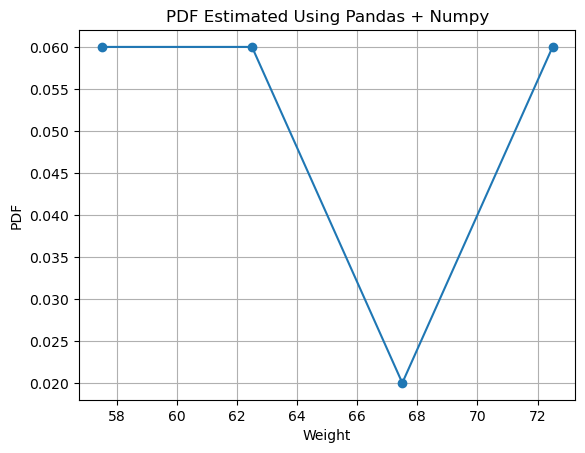

In [10]:
plt.plot(bin_centers, pdf, marker="o")
plt.xlabel("Weight")
plt.ylabel("PDF")
plt.title("PDF Estimated Using Pandas + Numpy")
plt.grid()
plt.show()


In [2]:
# Creating the helper functions for non visual analysis
def discrete_non_viz_analysis(data):
    '''
    This function performs a complete statistical
    analysis of discrete data (categorical and numerical).
    '''
    series = pd.Series(data)
    print(series.agg(['count', 'nunique', 'unique']))
    print('Value Counts: \n', series.value_counts())
    print()


def continuous_non_viz_analysis(data):
    '''
    This function performs a complete statistical
    analysis of continuous numerical data.
    '''
    series = pd.Series(data)
    print(series.agg(['count', 'min', 'max', 'mean', 'median', 'var', 'std', 'skew', 'kurt']).round(2))
    print()

In [3]:
# Creating the helper functions for visual analysis
def discrete_viz_analysis(data):
    '''
    This function performs a complete visual
    analysis of discrete data (categorical and numerical).
    '''
    fig, ax = plt.subplots(figsize=(5, 3), constrained_layout=True)
    fig.suptitle("Discrete Distribution Plot")

    ax.set_title("Count Plot")
    sns.countplot(x=data, ax=ax)

    plt.xticks(rotation=45)
    plt.show()



def continuous_viz_analysis(data):
    '''
    This function performs a complete visual
    analysis of continuous numerical data.
    '''

    fig, axes = plt.subplots(1, 3, figsize=(8, 3), constrained_layout=True)
    fig.suptitle("Continuous Distribution Plot")

    axes[0].set_title("Histogram Plot")
    sns.histplot(data, ax=axes[0])

    axes[1].set_title("KDE Plot")
    sns.kdeplot(data, fill=True, ax=axes[1])

    axes[2].set_title("Box Plot")
    sns.boxplot(data, ax=axes[2])

    plt.show()

In [4]:
def bernoulli_distribution_generator(p, size):
    # Define the number of trials (n) and the probability of success (p)
    return np.random.binomial(n=1, p=p, size=size)

count       10000
nunique         2
unique     [1, 0]
dtype: object
Value Counts: 
 1    6900
0    3100
Name: count, dtype: int64



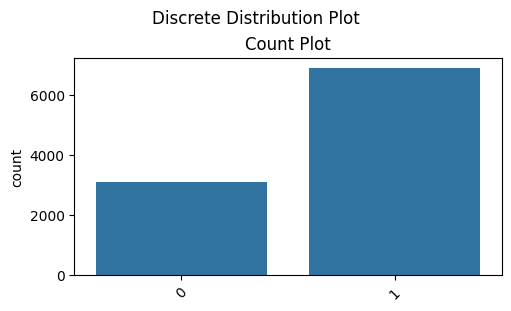

In [6]:
bernoulli_dist = bernoulli_distribution_generator(p=0.70, size=10000)
discrete_non_viz_analysis(data=bernoulli_dist)
discrete_viz_analysis(data=bernoulli_dist) 

In [8]:
p=0.6
var=stats.bernoulli.rvs(p=p,size=1000)
print(stats.bernoulli.pmf(k=0,p=p))
print(stats.bernoulli.pmf(k=1,p=p))

0.4000000000000001
0.6


In [9]:
df=pd.read_csv(r"C:\Users\masir\Downloads\Datasets\loan_data_set.csv")

In [12]:
df['Loan_Status']=df['Loan_Status'].map({'Y':1,'N':0})

In [14]:
discrete_non_viz_analysis(data=df['Loan_Status'])

count         614
nunique         2
unique     [1, 0]
Name: Loan_Status, dtype: object
Value Counts: 
 Loan_Status
1    422
0    192
Name: count, dtype: int64



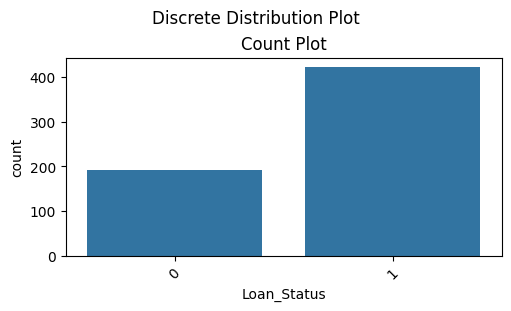

In [15]:
discrete_viz_analysis(data=df['Loan_Status']) 

In [16]:
p=422/614
print(stats.bernoulli.pmf(k=0,p=p))
print(stats.bernoulli.pmf(k=1,p=p))

0.31270358306188933
0.6872964169381107


In [18]:
def binomial_distribution_generator(n, p, size):
    # Define the number of trials (n) and the probability of success (p)
    return np.random.binomial(n=n, p=p, size=size)

count                               10000
nunique                                10
unique     [3, 2, 4, 5, 1, 6, 7, 0, 9, 8]
dtype: object
Value Counts: 
 3    2624
2    2309
4    2060
1    1186
5    1059
6     374
0     300
7      78
8       8
9       2
Name: count, dtype: int64



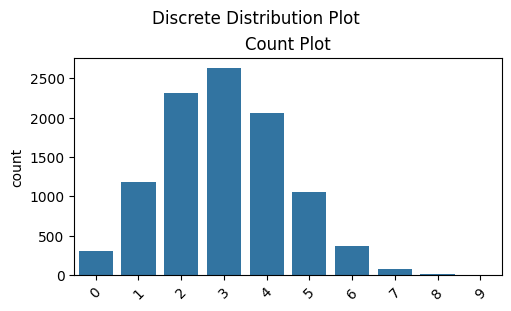

In [20]:
binomial_dist = binomial_distribution_generator(n=10, p=0.30, size=10000)
discrete_non_viz_analysis(data=binomial_dist)
discrete_viz_analysis(data=binomial_dist)

count                               10000
nunique                                10
unique     [1, 4, 3, 6, 2, 5, 7, 0, 8, 9]
dtype: object
Value Counts: 
 3    2600
2    2350
4    1989
1    1265
5    1024
6     381
0     283
7      93
8      14
9       1
Name: count, dtype: int64



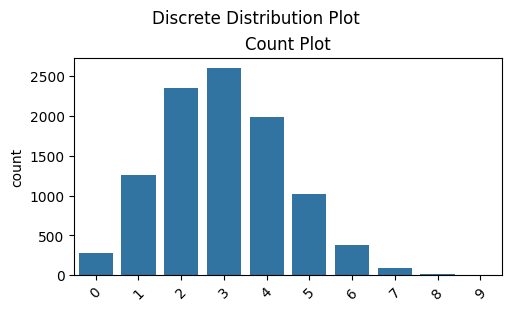

Probability of 0 success out of 10 trials: 0.02824752490000002
Probability of 1 success out of 10 trials: 0.12106082099999992
Probability of 2 successes out of 10 trials: 0.23347444050000013
Probability of <= 2 sucess out of 10 trials: 0.38278278639999974
Probability of 3 successes out of 10 trials: 0.2668279319999998
Probability of <= 3 sucess out of 10 trials: 0.6496107184000001
Probability of 4 successes out of 10 trials: 0.2001209489999999
Probability of <= 4 sucess out of 10 trials: 0.8497316674000001


In [24]:
# Using scipy.stats to generate the binomial distribution
n_trials = 10
prob_success = 0.30

var = stats.binom.rvs(n=n_trials, p=prob_success, size=10000)

discrete_non_viz_analysis(data=var)

discrete_viz_analysis(data=var)

# Computing PMF and CDF

print("Probability of 0 success out of 10 trials:", stats.binom.pmf(k=0, n=n_trials, p=prob_success))

print("Probability of 1 success out of 10 trials:", stats.binom.pmf(k=1, n=n_trials, p=prob_success))

print("Probability of 2 successes out of 10 trials:", stats.binom.pmf(k=2, n=n_trials, p=prob_success))

print("Probability of <= 2 sucess out of 10 trials:", stats.binom.cdf(k=2, n=n_trials, p=prob_success))

print("Probability of 3 successes out of 10 trials:", stats.binom.pmf(k=3, n=n_trials, p=prob_success))
print("Probability of <= 3 sucess out of 10 trials:", stats.binom.cdf(k=3, n=n_trials, p=prob_success))

print("Probability of 4 successes out of 10 trials:", stats.binom.pmf(k=4, n=n_trials, p=prob_success))
print("Probability of <= 4 sucess out of 10 trials:", stats.binom.cdf(k=4, n=n_trials, p=prob_success))

In [25]:
def poisson_distribution_generator(lam, size):
    # Define expected number of events occurring in a fixed-time interval (lam)
    return np.random.poisson(lam=lam, size=size)

count                                                  10000
nunique                                                   41
unique     [27, 32, 29, 24, 34, 36, 37, 26, 28, 30, 19, 4...
dtype: object
Value Counts: 
 30    737
29    723
31    714
28    707
27    648
32    637
26    609
33    581
34    523
25    499
35    470
24    408
36    358
23    328
37    306
22    284
38    252
39    188
21    185
40    151
20    124
41    115
19    100
42     74
18     63
43     44
17     36
44     33
45     24
16     16
46     12
49      9
15      9
47      8
48      8
14      7
50      5
13      2
51      1
56      1
53      1
Name: count, dtype: int64



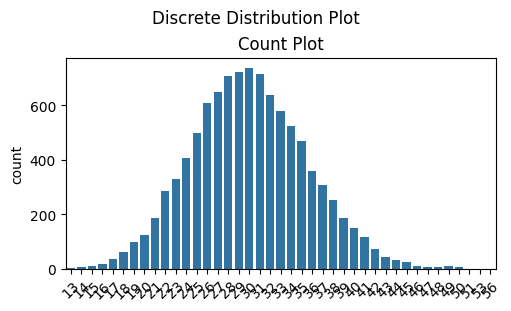

In [26]:
poisson_dist = poisson_distribution_generator(lam=30, size=10000)

discrete_non_viz_analysis(data=poisson_dist)

discrete_viz_analysis(data=poisson_dist)

In [27]:
continuous_non_viz_analysis(poisson_dist)

count     10000.00
min          13.00
max          56.00
mean         30.03
median       30.00
var          30.44
std           5.52
skew          0.21
kurt          0.08
dtype: float64



count                                                  10000
nunique                                                   39
unique     [27, 29, 37, 34, 26, 40, 22, 24, 19, 25, 18, 3...
dtype: object
Value Counts: 
 30    741
29    713
31    712
32    678
28    671
27    615
33    595
26    559
34    533
25    492
35    472
24    431
36    419
23    352
37    340
22    265
21    232
38    229
39    190
40    143
20    107
41    101
19     78
42     64
18     62
43     46
44     26
17     26
45     26
16     25
46     16
47     11
15     11
48      6
50      5
14      4
49      2
13      1
51      1
Name: count, dtype: int64



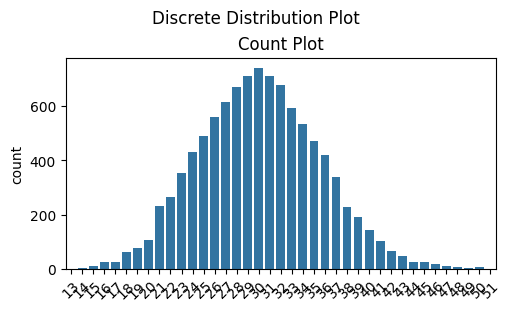

Probability of 20 events happening, given that on an average 30 events happen: 0.013411150012837837
Probability of 25 events happening, given that on an average 30 events happen: 0.05111533742894147
Probability of 35 events happening, given that on an average 30 events happen: 0.045308200086552224
Probability of <= 35 events happening, given that on an average 30 events happen:: 0.8426165255696685


In [28]:
# Using scipy.stats to generate the poisson distribution
lambda_=30

var = stats.poisson.rvs(mu=lambda_, size=10000)

discrete_non_viz_analysis(data=var)

discrete_viz_analysis(data=var)

# Computing PMF and CDF

print("Probability of 20 events happening, given that on an average 30 events happen:", stats.poisson.pmf(k=20, mu=lambda_))

print("Probability of 25 events happening, given that on an average 30 events happen:", stats.poisson.pmf(k=25, mu=lambda_))

print("Probability of 35 events happening, given that on an average 30 events happen:", stats.poisson.pmf(k=35, mu=lambda_)
print("Probability of <= 35 events happening, given that on an average 30 events happen::", stats.poisson.cdf(k=35, mu=lambda_))

      

In [30]:
print("Probability of 40 events happening, given that on an average 30 events happen:", stats.poisson.pmf(k=40, mu=lambda_))
print("Probability of <= 40 events happening, given that on an average 30 events happen::", stats.poisson.cdf(k=40, mu=lambda_))

Probability of 40 events happening, given that on an average 30 events happen: 0.013943463479967897
Probability of <= 40 events happening, given that on an average 30 events happen:: 0.9676904258341258


In [32]:
# A customer can choose one of 3 products:

# Product	Probability
# A	0.5
# B	0.3
# C	0.2

# You observe 10 customers.

# You want the probability that:

# 5 choose A

# 3 choose B

# 2 choose C

# 👉 Multinomial distribution
n = 10
p = [0.5, 0.3, 0.2]
x = [5, 3, 2]

stats.multinomial.pmf(x, n=n, p=p)

0.08504999999999999